# 08 · Exploratory Data Analysis: Finding Outliers

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Detect and remove compensation outliers, then check how age correlates with the other numeric variables.

**Data:** Stack Overflow Developer Survey (IBM Skills Network copy, 65,437 responses × 114 columns)

**Tools:** pandas, Matplotlib, Seaborn

### Key results
- Software Development is by far the largest industry (11,918 respondents).
- Mean compensation $86,155 vs median $65,000: the distribution is strongly right-skewed.
- IQR method: upper bound $220,861 → **978 outliers** removed (65,437 → 64,459 rows).
- Age is strongly correlated with work experience (r = 0.85) and moderately with compensation (r = 0.37).

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 07](07_eda_data_distribution.ipynb) · [Project README](../README.md) · [09 →](09_eda_correlation.ipynb)

In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [8]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [10]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


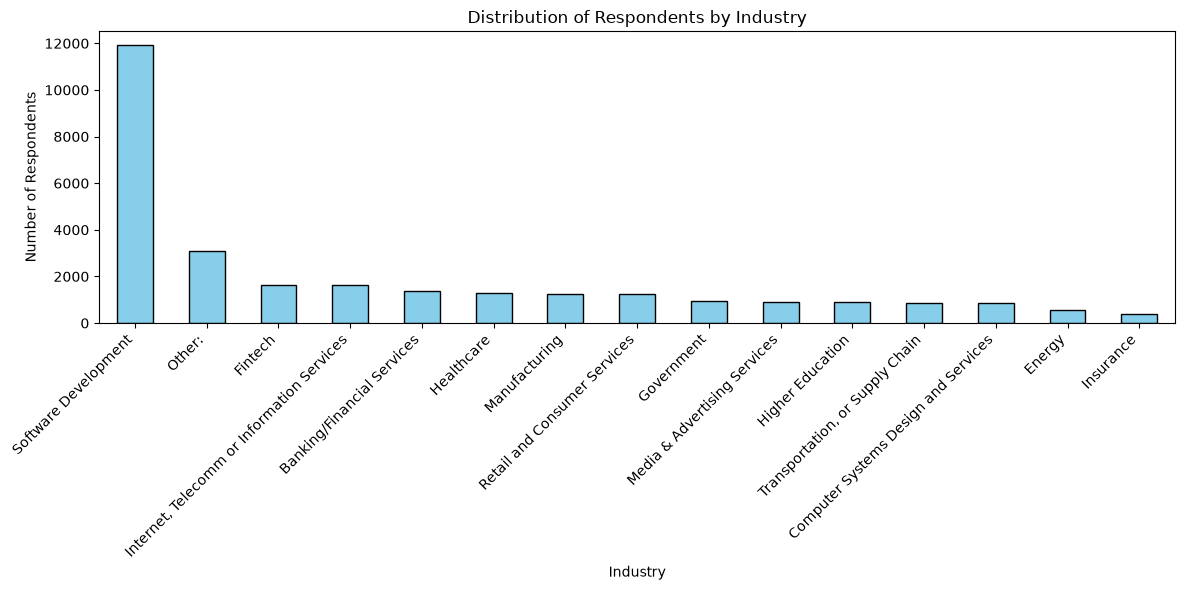

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Name: count, dtype: int64

In [11]:
# Step 2: distribution of respondents by Industry
industry_counts = df['Industry'].value_counts()

plt.figure(figsize=(12, 6))
industry_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Respondents by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Main trends: the most represented industries
print(industry_counts.head(5))

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


**Approach:** a first, simple rule flags values more than three standard deviations above the mean (89 respondents).

In [9]:
# Step 3: basic statistics and "high" outliers (> mean + 3 standard deviations)
comp = df['ConvertedCompYearly'].dropna()

mean_comp = comp.mean()
median_comp = comp.median()
std_comp = comp.std()
print(f"Mean: {mean_comp:,.2f}")
print(f"Median: {median_comp:,.2f}")
print(f"Standard Deviation: {std_comp:,.2f}")

threshold = mean_comp + 3 * std_comp
print(f"Threshold (mean + 3*std): {threshold:,.2f}")

high_comp_outliers = df[df['ConvertedCompYearly'] > threshold]
print(f"Number of high compensation outliers: {len(high_comp_outliers)}")
high_comp_outliers[['ConvertedCompYearly']].sort_values('ConvertedCompYearly', ascending=False).head(10)

Mean: 86,155.29
Median: 65,000.00
Standard Deviation: 186,756.97
Threshold (mean + 3*std): 646,426.21Number of high compensation outliers: 89

,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0
19267,3367716.0
23694,2584118.0
33720,2237846.0
34523,2153432.0
13763,2048046.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


**Approach:** the IQR rule (below Q1 − 1.5·IQR or above Q3 + 1.5·IQR) is less affected by the extreme values that inflate the standard deviation. This is the threshold used in the presentation.

Q1: 32,712.00 | Q3: 107,971.50 | IQR: 75,259.50
Lower bound: -80,177.25 | Upper bound: 220,860.75
Number of outliers (IQR): 978

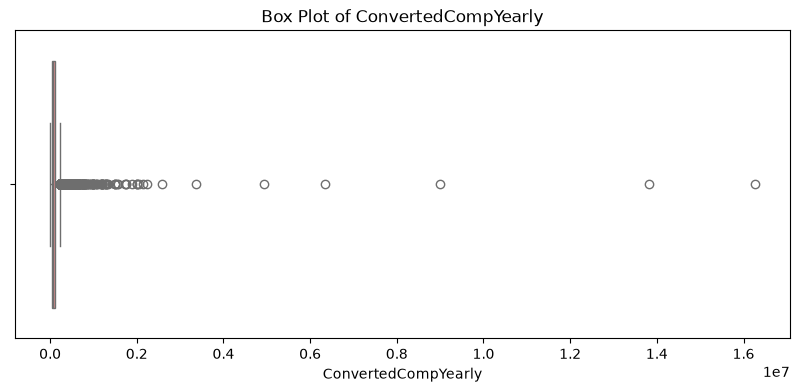

In [12]:
# Step 4: outliers with the IQR method
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Lower bound: {lower_bound:,.2f} | Upper bound: {upper_bound:,.2f}")

outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f"Number of outliers (IQR): {len(outliers)}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['ConvertedCompYearly'], color='lightcoral')
plt.title('Box Plot of ConvertedCompYearly')
plt.xlabel('ConvertedCompYearly')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


Original size: (65437, 114)
Size without outliers: (64459, 114)
Rows removed: 978

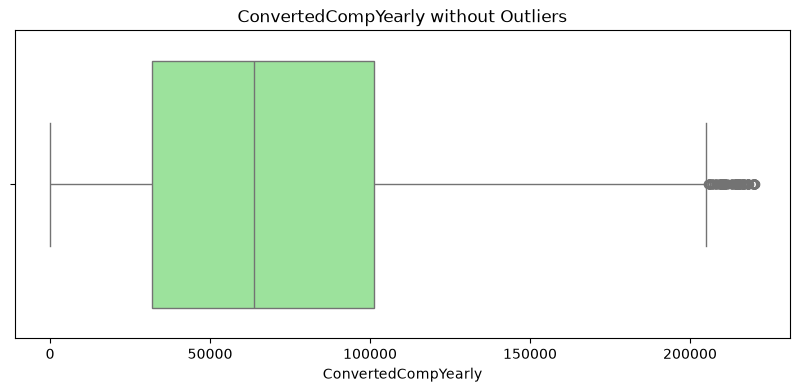

In [13]:
# Step 5: new DataFrame without outliers (missing values are kept)
outlier_mask = (df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)
df_no_outliers = df[~outlier_mask].copy()

print(f"Original size: {df.shape}")
print(f"Size without outliers: {df_no_outliers.shape}")
print(f"Rows removed: {len(df) - len(df_no_outliers)}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_no_outliers['ConvertedCompYearly'], color='lightgreen')
plt.title('ConvertedCompYearly without Outliers')
plt.show()

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


**Approach:** `Age` ranges are mapped to their midpoints so that age can enter the correlation matrix.

Correlation of Age_numeric with other numeric columns:
WorkExp                0.848530
ConvertedCompYearly    0.371556
JobSat                 0.067792
CompTotal             -0.002743
JobSatPoints_1        -0.029089
JobSatPoints_8        -0.046238
JobSatPoints_6        -0.049861
JobSatPoints_4        -0.075343
JobSatPoints_9        -0.080869
JobSatPoints_7        -0.081377
JobSatPoints_5        -0.100816
JobSatPoints_11       -0.106338
JobSatPoints_10       -0.112720
Name: Age_numeric, dtype: float64

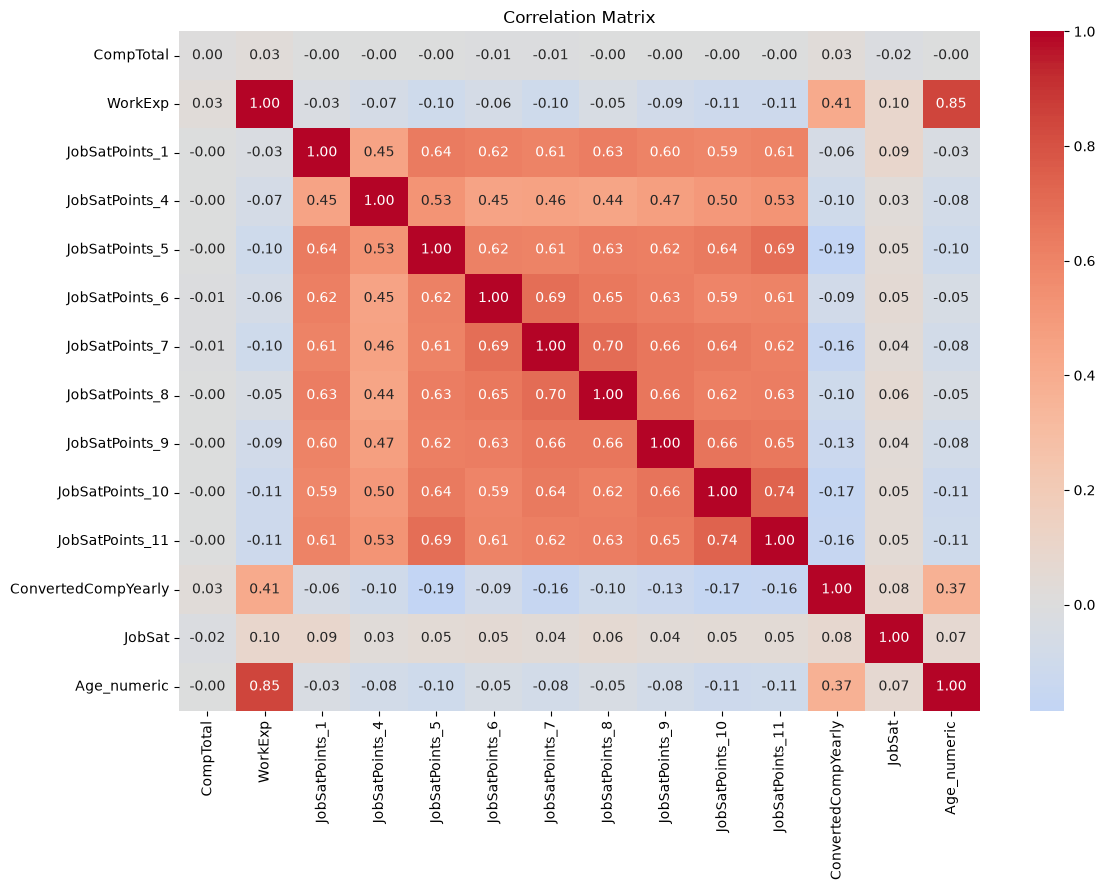

In [14]:
# Step 6: Age -> approximate numeric value (midpoint of the range)
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65,
    'Prefer not to say': None
}
df_no_outliers['Age_numeric'] = df_no_outliers['Age'].map(age_map)

# Numeric columns (ResponseId is excluded: it has no statistical meaning)
numeric_df = df_no_outliers.select_dtypes(include='number').drop(columns=['ResponseId'], errors='ignore')

corr_matrix = numeric_df.corr()
print("Correlation of Age_numeric with other numeric columns:")
print(corr_matrix['Age_numeric'].drop('Age_numeric').sort_values(ascending=False))

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
